# Agent Trade Visualiser
**PoliMi GSOM Algorithmic Trading 2026**

Runs a full RMSC04 day for **one student agent** (with order logging enabled)
and overlays every executed buy and sell on the mid-price chart.
A second panel tracks the agent's running inventory throughout the day.

---
**How to use:**  
Edit the two lines in *Section 1* to pick the agent you want to inspect,
then *Run All*.

## 0 · Imports

In [1]:
import os, sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from abides_core import abides
from abides_core.utils import parse_logs_df, ns_date, str_to_ns, fmt_ts
from abides_markets.configs.rmsc04 import build_config
from abides_markets.utils import config_add_agents
from abides_markets.orders import Side

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

## 1 · Choose the agent to inspect

In [2]:
# ── Import your agent ────────────────────────────────────────────────────
from student_work.optimized_agent import OptimizedAgent as AgentClass
TEAM_LABEL = "OptimizedAgent"

# ─────────────────────────────────────────────────────────────────────────

SEED         = 110
END_TIME     = "17:30:00"   # use "10:00:00" for a quick preview
TICKER       = "ABM"
STARTING_CASH = 10_000_000  # cents

## 2 · Run the simulation

The background market is standard RMSC04 (MomentumAgents removed).
Only the student agent has `log_orders=True`; background agents log nothing,
so memory stays manageable.

In [3]:
np.random.seed(SEED)

# Background market — no momentum agents, no per-order logging
cfg = build_config(
    seed=SEED,
    end_time=END_TIME,
    num_momentum_agents=0,
    log_orders=False,
    exchange_log_orders=False,
    book_logging=True,        # needed for the price chart
    book_log_depth=1,
    stdout_log_level="WARNING",
    starting_cash=STARTING_CASH,
)

# Student agent — log_orders=True so ORDER_EXECUTED events are recorded
student_id = len(cfg["agents"])
student = AgentClass(
    id=student_id,
    name=TEAM_LABEL,
    type=AgentClass.__name__,
    symbol=TICKER,
    starting_cash=STARTING_CASH,
    random_state=np.random.RandomState(seed=np.random.randint(0, 2**32)),
    log_orders=True,           # ← captures every fill
)

cfg = config_add_agents(cfg, [student])

print(f"Running simulation for: {TEAM_LABEL}  (seed={SEED}, end={END_TIME})")
end_state = abides.run(cfg)
print("Done.")

Running simulation for: I trade at noon  (seed=110, end=17:30:00)
Done.


## 3 · Extract price and trade data

In [4]:
# ── Mid-price from L1 order-book snapshots ────────────────────────────────
ob  = end_state["agents"][0].order_books[TICKER]
L1  = ob.get_L1_snapshots()

bids = pd.DataFrame(L1["best_bids"], columns=["time", "price", "qty"]).dropna(subset=["time"])
asks = pd.DataFrame(L1["best_asks"], columns=["time", "price", "qty"]).dropna(subset=["time"])

# Convert nanosecond timestamps to seconds-from-midnight for readability
def to_tod_s(ns_arr):
    """Nanosecond epoch → seconds from midnight (float).
    Snapshots taken before one side of the book has any quote carry a None
    timestamp; dropna() above removes them, and the explicit cast guarantees
    float64 dtype (required by merge_asof).
    """
    return ((ns_arr - ns_arr.apply(ns_date)) / 1e9).astype(float)

bids["tod"] = to_tod_s(bids["time"])
asks["tod"] = to_tod_s(asks["time"])

# Align bid/ask on a common time grid and compute mid
price = pd.merge_asof(
    bids[["tod", "price"]].rename(columns={"price": "bid"}),
    asks[["tod", "price"]].rename(columns={"price": "ask"}),
    on="tod",
)
# L1 price entries can be Python None (empty book side) → force numeric,
# then drop any rows where either side is still missing.
price["bid"] = pd.to_numeric(price["bid"], errors="coerce")
price["ask"] = pd.to_numeric(price["ask"], errors="coerce")
price = price.dropna(subset=["bid", "ask"])
price["mid"] = (price["bid"] + price["ask"]) / 2

print(f"Price observations: {len(price):,}")


Price observations: 70,162


In [5]:
# ── ORDER_EXECUTED events for the student agent ───────────────────────────
logs = parse_logs_df(end_state)

mask  = (logs["agent_id"] == student_id) & (logs["EventType"] == "ORDER_EXECUTED")
fills = logs[mask].copy()

if fills.empty:
    print("⚠  No executed orders found — the agent may not have traded today.")
else:
    # Derive absolute open/close timestamps for the simulation date.
    # ns_date() returns midnight of the day for any nanosecond timestamp,
    # and str_to_ns() returns a nanosecond duration, so their sum is an
    # absolute timestamp anchored to the correct calendar date.
    sim_midnight    = ns_date(fills["EventTime"].iloc[0])
    MARKET_OPEN_NS  = sim_midnight + str_to_ns("09:30:00")
    MARKET_CLOSE_NS = sim_midnight + str_to_ns("17:30:00")

    fills["tod"] = (fills["EventTime"] - fills["EventTime"].apply(ns_date)) / 1e9
    fills["is_buy"]   = fills["side"].apply(lambda s: s.is_bid())
    fills["price_k"]  = fills["fill_price"] / 100      # cents → dollars
    fills["signed_qty"] = fills.apply(
        lambda r: r["quantity"] if r["is_buy"] else -r["quantity"], axis=1
    )
    fills["inventory"] = fills["signed_qty"].cumsum()

    buys  = fills[fills["is_buy"]]
    sells = fills[~fills["is_buy"]]
    print(f"Executed orders: {len(fills)}  "
          f"({len(buys)} buys, {len(sells)} sells)")


Executed orders: 291  (145 buys, 146 sells)


## 4 · Price, trades, inventory & intraday P&L

Three stacked panels sharing one time axis: executed trades on the
mid-price chart, the running inventory, and the agent's intraday
mark-to-market P&L (open inventory valued at the mid-price).

Final intraday P&L (mid-marked): $966.57


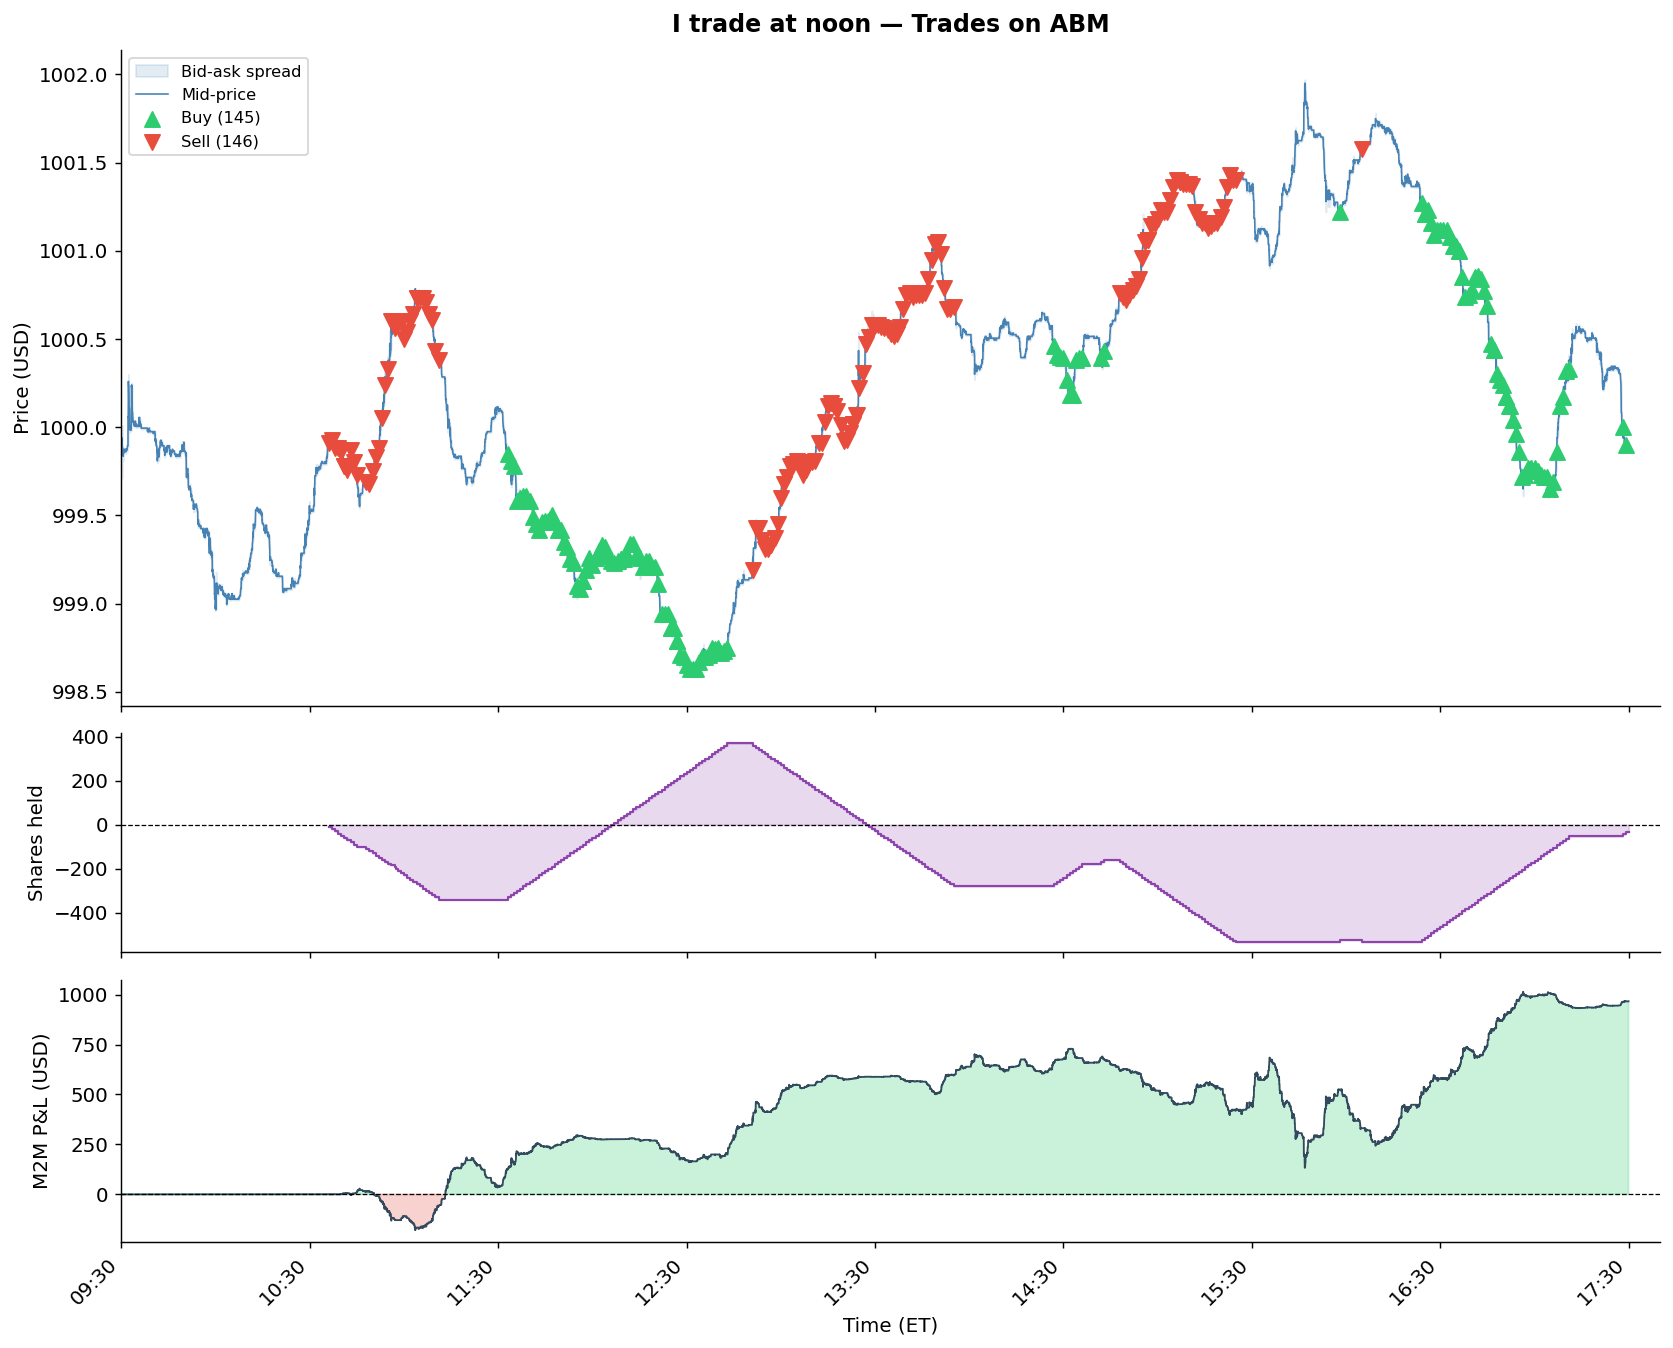

In [6]:
def fmt_xaxis(ax, start_s=9.5*3600, end_s=17.5*3600, step_s=3600,
              right_pad_s=10*60):
    """Label the x-axis as HH:MM, with a small breathing-room pad."""
    ticks = np.arange(start_s, end_s + 1, step_s)
    labels = [f"{int(t//3600):02d}:{int((t%3600)//60):02d}" for t in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlim(start_s, end_s + right_pad_s)


def expand_step(x, y, end_x=None):
    """Pre-expand step-post data into explicit (x, y) sequences.

    matplotlib's fill_between(step='post') draws the lower boundary of the
    filled region as a visible horizontal edge, creating a floating-bar
    artefact on long flat sections.  Pre-expanding the step series and using
    a plain fill_between (no step= argument) avoids this entirely.

    If end_x is given, the last value is extended to that x coordinate so
    the chart isn't clipped at the final fill event.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    # interleave: each x repeated twice, shifted by one
    x_out = np.repeat(x, 2)[1:]
    y_out = np.repeat(y, 2)[:-1]
    if end_x is not None:
        x_out = np.append(x_out, float(end_x))
        y_out = np.append(y_out, y[-1])
    return x_out, y_out


# ── Intraday mark-to-market P&L ───────────────────────────────────────────
# Reconstruct the agent's cash from its fills: every execution moves CASH by
# -(signed_qty * fill_price), exactly as TradingAgent.order_executed does.
# RMSC04 charges no commission, so the fill log alone reproduces the cash
# trajectory.  Open inventory is marked to the prevailing mid-price:
#     PnL(t) = [cash(t) - starting_cash] + inventory(t) * mid(t)
# Note: Section 5 marks inventory to last_trade rather than mid, so its
# final figure differs from this curve's endpoint by a few dollars.
if not fills.empty:
    pf = fills[["tod", "signed_qty", "fill_price", "inventory"]] \
        .sort_values("tod").copy()
    pf["cash"] = STARTING_CASH - (pf["signed_qty"] * pf["fill_price"]).cumsum()

    # Align cash & inventory (step functions, changing only at fills) onto
    # the price grid; both stay flat at their starting values before fill #1.
    pnl = pd.merge_asof(
        price[["tod", "mid"]],
        pf[["tod", "cash", "inventory"]],
        on="tod",
    )
    pnl["cash"]      = pnl["cash"].fillna(STARTING_CASH)
    pnl["inventory"] = pnl["inventory"].fillna(0)
    pnl["pnl"] = (pnl["cash"] + pnl["inventory"] * pnl["mid"]
                  - STARTING_CASH) / 100


fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(13, 10.5),
    gridspec_kw={"height_ratios": [3, 1, 1.2]},
    sharex=True,
)

# ── Panel 1: mid-price + bid-ask band + trades ────────────────────────────
ax1.fill_between(
    price["tod"], price["bid"] / 100, price["ask"] / 100,
    alpha=0.15, color="steelblue", label="Bid-ask spread",
)
ax1.plot(
    price["tod"], price["mid"] / 100,
    color="steelblue", linewidth=0.9, label="Mid-price",
)

if not fills.empty:
    ax1.scatter(
        buys["tod"], buys["fill_price"] / 100,
        marker="^", color="#2ecc71", s=70, zorder=5,
        label=f"Buy ({len(buys)})",
    )
    ax1.scatter(
        sells["tod"], sells["fill_price"] / 100,
        marker="v", color="#e74c3c", s=70, zorder=5,
        label=f"Sell ({len(sells)})",
    )

ax1.set_ylabel("Price (USD)")
ax1.set_title(f"{TEAM_LABEL} — Trades on {TICKER}", fontweight="bold", pad=10)
ax1.legend(loc="upper left", fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

# ── Panel 2: running inventory ────────────────────────────────────────────
if not fills.empty:
    END_TOD = 17.5 * 3600

    x_inv, y_inv = expand_step(
        fills["tod"].values, fills["inventory"].values, end_x=END_TOD
    )
    ax2.plot(x_inv, y_inv, color="#8e44ad", linewidth=1.2, label="Inventory")
    ax2.fill_between(x_inv, y_inv, 0, alpha=0.2, color="#8e44ad")
else:
    ax2.text(0.5, 0.5, "No trades", ha="center", va="center",
             transform=ax2.transAxes, color="grey")

ax2.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax2.set_ylabel("Shares held")
ax2.spines[["top", "right"]].set_visible(False)

# ── Panel 3: intraday mark-to-market P&L ──────────────────────────────────
if not fills.empty:
    ax3.plot(pnl["tod"], pnl["pnl"], color="#34495e", linewidth=1.0)
    ax3.fill_between(pnl["tod"], pnl["pnl"], 0, where=pnl["pnl"] >= 0,
                     color="#2ecc71", alpha=0.25, interpolate=True)
    ax3.fill_between(pnl["tod"], pnl["pnl"], 0, where=pnl["pnl"] < 0,
                     color="#e74c3c", alpha=0.25, interpolate=True)
else:
    ax3.text(0.5, 0.5, "No trades", ha="center", va="center",
             transform=ax3.transAxes, color="grey")

ax3.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax3.set_ylabel("M2M P&L (USD)")
ax3.set_xlabel("Time (ET)")
ax3.spines[["top", "right"]].set_visible(False)

fmt_xaxis(ax3)
fig.tight_layout()

if not fills.empty:
    print(f"Final intraday P&L (mid-marked): ${pnl['pnl'].iloc[-1]:,.2f}")

## 5 · Trade summary table

In [7]:
if not fills.empty:
    summary = (
        fills.groupby("is_buy")
        .agg(
            count=("quantity", "count"),
            total_shares=("quantity", "sum"),
            avg_fill=("fill_price", "mean"),
            min_fill=("fill_price", "min"),
            max_fill=("fill_price", "max"),
        )
        .rename(index={True: "Buy", False: "Sell"})
    )
    for col in ["avg_fill", "min_fill", "max_fill"]:
        summary[col] = (summary[col] / 100).map("${:.2f}".format)
    display(summary)

    final_agent = [a for a in end_state["agents"] if a.id == student_id][0]
    final_mtm   = final_agent.mark_to_market(final_agent.holdings)
    pnl_dollars = (final_mtm - STARTING_CASH) / 100
    eod_pos     = final_agent.holdings.get(TICKER, 0)

    sign = "▲" if pnl_dollars >= 0 else "▼"
    print(f"\nEnd-of-day position : {eod_pos:+d} shares")
    print(f"Final PnL           : {sign} ${abs(pnl_dollars):,.2f}")

,count,total_shares,avg_fill,min_fill,max_fill
is_buy,,,,,
Sell,146,1373.0,$1000.47,$999.19,$1001.58
Buy,145,1340.0,$999.77,$998.63,$1001.27



End-of-day position : -33 shares
Final PnL           : ▲ $966.73
